# ALPACA 2.0

Unlike a real alpaca, ALPACA **(Advanced Learning Platform for Analog Circuits and Automation)** is a device equipped with several digital tools to be your guide in introduction to digital systems and electronics. 

ALPACA features **2 Raspberry Pico2 microcontrollers:**
- **Student Pico:** for you to program and be able to create signals/generate signals
- **Helper Pico:** preprogrammed to control several board's functionalities

Student Pico is labeled `Pi Pico 1` and located at the top right of the board; whereas, Helper Pico is labeled `Pi Pico 2` and is located below.

```{admonition} Connect to Student Pico
:class: warning
You must always connect and program Student Pico. The Helper Pico is meant to be untouched and controls the board on its own.
```

## Getting Started

ALPACA requires to be powered by the **USB-C power port** found on top left. Once you turn on the ON/OFF switch ALPACA should power up.

```{tip}
You can configure the ALPACA to power on only when a Pico is connected to a computer.

By adjusting the jumper on the `J502` pins located on the top right of the board:

- **Configuration A (Jumper on 1&2):** The board powers on only when both the USB-C power cable is connected and the Pico is connected to a computer.

- **Configuration B (Jumper on 2&3):** The board powers on as long as the USB-C power cable is connected.
```

If the screen lights up and displays information, congrats! Your ALPACA is awake!

### Screen and Toolkit

ALPACA is equipped with several tools, these tools use the screen to display information. To cycle between available tools you can use the <font color="#0e4ed9">**FUNCTION button**</font> located next to the screen.

<span style="background:#ff1493;color:#fff;padding:2px 8px;border-radius:4px;font-weight:700;font-size:0.85em;box-shadow:0 0 6px rgba(255,20,147,0.6);">🚩 TODO: add picture of the screens and relevant pins.</span>

**`VOLT` Voltmeter** reads out the voltage connected to the `VOLTMETER-IN` pin located below the Helper Pico. It can read between voltages +15V and -15V.


**`COMP` Component Tester** determines the component type (resistor, capacitor or diode) placed on the `COMPONENT-TESTER` plates or connected to the pins. It is useful to quickly identify resistor's value or a diode's direction.

**`CSTM` Custom Screen** displays any text defined with the `set_screen_text` function, allowing custom messages or values to be shown on screen.

<span style="background:#ff1493;color:#fff;padding:2px 8px;border-radius:4px;font-weight:700;font-size:0.85em;box-shadow:0 0 6px rgba(255,20,147,0.6);">🚩 TODO: set_screen_text might change.</span>

**`INFO` Information** screen displays information regarding the Helper Pico and a fun message.

### Background: Digital vs Analog Signals

Signals differ by their nature, **<font color="#9f1ceb">digital</font>** and **<font color="#eb871c">analog</font>**. Both of them are used transmit information but in different formats.

**<font color="#9f1ceb">Digital signals</font>** can be either **ON or OFF** high voltage or low voltage, 1 or 0, TRUE or FALSE, High or Low... They are binary therefore minor electronic noise does not affect the signal's integrity.

**<font color="#eb871c">Analog signals</font>** are continous and smooth, like a sine-wave. Unlike digital, they **can take on any value within a defined range**. Because they are continuous, they are highly sensitive to electronic noise.

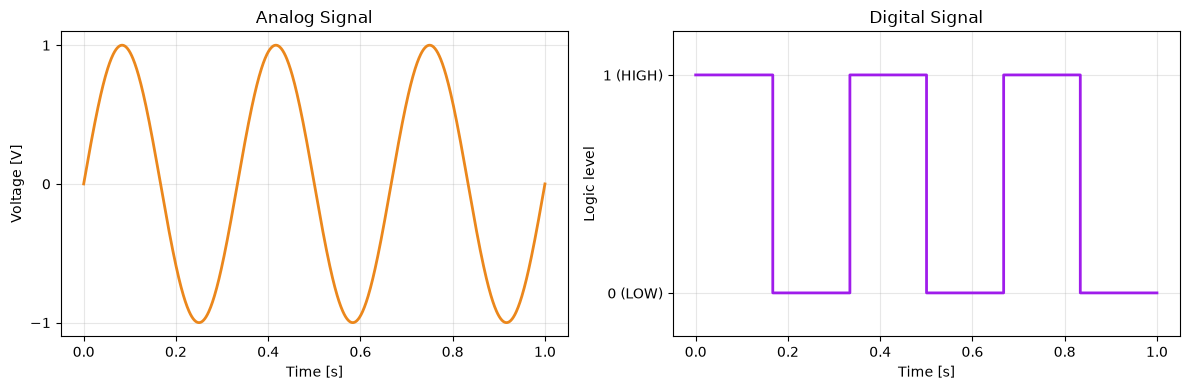

In [9]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 1, 1000)
f = 3

analog = np.sin(2 * np.pi * f * t)
digital = (np.sin(2 * np.pi * f * t) >= 0).astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

ax1.plot(t, analog, color="#eb871c", linewidth=2)
ax1.set_title("Analog Signal")
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Voltage [V]")
ax1.set_yticks([-1, 0, 1])
ax1.grid(alpha=0.3)

ax2.step(t, digital, color="#9f1ceb", linewidth=2, where="post")
ax2.set_title("Digital Signal")
ax2.set_xlabel("Time [s]")
ax2.set_ylabel("Logic level")
ax2.set_yticks([0, 1])
ax2.set_yticklabels(["0 (LOW)", "1 (HIGH)"])
ax2.set_ylim(-0.2, 1.2)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

You can use the digital pins <font color="#bd76e7">**DI (Digital Input)**</font> and <font color="#610a93">**DO (Digital Output)**</font> to receive/create digital signals from the ALPACA.

To <font color="#ea9943">capture analog signals</font> you need to use <font color="#ea9943">**ADC** (Analog-to-Digital Convertor)</font> and to <font color="#9e5508">generate</font> them you need to use the <font color="#9e5508">**function generator**</font>.

<span style="background:#ff1493;color:#fff;padding:2px 8px;border-radius:4px;font-weight:700;font-size:0.85em;box-shadow:0 0 6px rgba(255,20,147,0.6);">🚩 TODO: add picture of DO, DI, ADC and DAC.</span>


## Programming with ALPACA

ALPACA runs a special version of Python called MicroPython on its own. Therefore, you have to send your code for ALPACA to execute it.

Therefore, a package called **Belay** allows you to easily send and run bits of your python code on the ALPACA.



### Running your first code

After connecting the ALPACA to your computer via USB you can access the device:

In [ ]:
from belay import Device, list_devices

# 'list_devices()' gets all connected boards to your computer
# and the first element is most likely the ALPACA. 
pico = Device(list_devices()[0].to_port())

To identify which code part needs to be seen by the ALPACA and which code part needs to be seen by your computer, you can 'tag' functions that will be executed in ALPACA using `@pico.task`

In [ ]:
@pico.task
def hello():
    print("Hello from ALPACA!")

hello() # Will be executed inside the ALPACA

:::{important}
The **ALPACA environment** and your **computer environment** are completely separate: variables and packages (like numpy) are **not shared** between them. To move data across, you must **send/receive it via arguments and return values**.
:::

:::{admonition} DON'T
:class: danger

Here, `i` is **not passed as an argument**, so ALPACA has no way to read or write it.

```python
i = 1

@pico.task
def increment():
    global i
    i += 1  # i not found

increment()
print(i)  # Even if it didn't error, it would print 1
```
:::

:::{admonition} DO
:class: tip

By passing `i` as an **argument**, Belay knows exactly what value to send to ALPACA, and what to retrieve back.

```python
i = 1

@pico.task
def increment(i):
    return i + 1

i = increment(i)
print(i)  # 2
```
:::

### Generating/Acquiring signals

As previously mentioned signals differ by **<font color="#9f1ceb">digital</font>** and **<font color="#eb871c">analog</font>** and with ALPACA there are several ways to acquire them.

#### Digital Signals

Generation and acquisition of <font color="#9f1ceb">digital signals</font> is fairly easy via the **digital pins (DI and DO)**. The digital pins

To access the digital pins on the ALPACA, use the `Pin` object from the module `machine`.

Pins can detect whether there's a HIGH or LOW voltage at their respective pins (essentially the digital signal).

**Pin(`pin_number`, `pin_type`, value=`value`)**

- `pin_number` is the number of the pin, for instance `DO10`'s pin number is `10`

- `pin_type` specifies what type of pin it is:
    - `Pin.OUT`: for outputing signals
    - `Pin.IN`: for receiving signals

- `value` valid only for `Pin.OUT` specifies initial output pin value if given

The following code will <font color="#610a93">**turn on the LED and later turn off**</font>

```python
@pico.task
def turn_on():
    global led
    from machine import Pin

    led = Pin(10, Pin.OUT, value=0) # Digital Output 10
    led.value(1) # Set DO10 to HIGH (3.3V)

@pico.task
def turn_off():
    led.value(0) # Set DO10 to LOW (0V)

turn_on()
input("Press ENTER to turn off the LED") # Waits until an input is given in the console
turn_off()
```


```{figure} images/alpaca_led_digital_output.avif
---
max-height: 300px
name: ALPACA Digital Output Example
class: no-invert
---
```

You can also use the same logic <font color="#bd76e7">**to read from a Pin**</font>

```python
@pico.task
def read_pin():
    from machine import Pin

    di14 = Pin(14, Pin.IN) # Digital Input 14
    return di14.value()

print(read_pin())
```


```{figure} images/alpaca_led_digital_input.avif
---
max-height: 300px
name: ALPACA Digital Input Example
class: no-invert
---
```

```{tip}
The digital pins have **high impedance (very high resistance)**, so you can treat them as if the wire isn't connected to anything else.
```


#### Analog Signals

<font color="#eb871c">Analog signals</font> can take any value and are continous. Since the chip is a digital system operating on 0s and 1s, you need to use need to use either <font color="#ea9943">**ADC** (Analog-to-Digital Converter)</font> for acquisition and  <font color="#9e5508">**DAC** (Digital-to-Analog Converter)</font> for generation.

Compared to digital signals, they are a bit different to use.

##### ADC (Analog-to-Digital)

On ALPACA there are 3 ADCs located: <font color="#ea9943"**Pins 26 (ADC0), 27 (ADC1), 28 (ADC2)**</font>. 

### Modules

Some modules aren't available in ALPACA and some modules aren't available in the computer. These are the **modules that are available on ALPACA only:**

#### `machine` - functions related to the hardware

This module contains functions to control hardware on ALPACA like the digital pins or the analog to digital converter.


#### `utime` - time related functions

When working with signals you need to deal with time-senstivity at microscale. `utime` provides functions for this exact purpose.

```python
@pico.task
def blink_led():
    '''Turns on the LED on DO10 and turns it off after 500ms'''
    from machine import Pin
    from utime import sleep_ms

    led = Pin(10, Pin.OUT) # Digital Output 10

    led.value(1)
    sleep_ms(500)
    led.value(0)
```


In boards, time is compared as <font color="#00819b">**ticks**</font>, they are just <font color="#00819b">a running clock, in milliseconds, since the board booted up.</font>

But the <font color="#00819b">tick</font> itself is never useful cause sometimes <font color="#00819b">**it rollsover to 0 (as it can't count forever)**</font>. Therefore, using `utime.ticks_add(a, b)` and `utime.ticks_diff(a, b)` (basically a + b and a - b) is <font color="#00819b">**essential**</font> when calculating time.

```python
@pico.task
def acquire_data():
    '''Samples for 500ms and returns the average'''
    import utime as time
    from machine import ADC

    adc0 = ADC(26)

    total = 0
    n = 0

    # 500ms in the future
    deadline = ticks_add(time.ticks_ms(), 500)

    # Run until deadline - now < 0, so until the deadline is passed
    while time.ticks_diff(deadline, time.ticks_ms()) < 0:
        n += 1
        total += adc0.read_u16()

    return total * 3.3 / 2**16 / n
```